<a href="https://colab.research.google.com/github/schnekenberg/tcc-burned-area-detection/blob/main/04_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **configurações de ambiente**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier # algoritmo Random Forest
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, accuracy_score
)
import xgboost as xgb # algoritmo XGBoost
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.metrics import roc_auc_score, roc_curve

drive.mount('/content/drive')

CSV_FOLDER = '/content/drive/MyDrive/CSV_files'
SEED = 42
BANDS = ['B2', 'B3', 'B4', 'B8', 'B12', 'NDVI', 'NBR']
FEATURE_COLS = [f'{stat}_{band}' for stat in ['mean', 'std'] for band in BANDS]

# carrega os datasets
train_df = pd.read_csv(f'{CSV_FOLDER}/train.csv')
val_df = pd.read_csv(f'{CSV_FOLDER}/val.csv')
test_df = pd.read_csv(f'{CSV_FOLDER}/test.csv')

x_train = train_df[FEATURE_COLS]
y_train = train_df['label']
x_val = val_df[FEATURE_COLS]
y_val = val_df['label']
x_test = test_df[FEATURE_COLS]
y_test = test_df['label']


# calcula scale_pos_weight para XGBoost
negativos = (y_train == 0).sum()
positivos = (y_train == 1).sum()
scale_pos_weight = negativos / positivos
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# modelos
models = {
    'Random Forest': RandomForestClassifier(
        class_weight = 'balanced',
        n_estimators = 100, # número de Decision Trees (DTs)
        random_state = SEED,
        n_jobs = -1
    ),
    'XGBoost': xgb.XGBClassifier(
        scale_pos_weight = scale_pos_weight,
        n_estimators = 100, # número de Decision Trees (DTs)
        random_state = SEED,
        eval_metric = 'logloss',
        verbosity = 0
    )
}

Mounted at /content/drive
scale_pos_weight: 5.82


# **treinamento e avaliação**


Treinando: Random Forest

--- Validação ---
              precision    recall  f1-score   support

Sem queimada       0.91      0.97      0.94     55608
Com queimada       0.70      0.44      0.54      9558

    accuracy                           0.89     65166
   macro avg       0.81      0.70      0.74     65166
weighted avg       0.88      0.89      0.88     65166


Treinando: XGBoost

--- Validação ---
              precision    recall  f1-score   support

Sem queimada       0.98      0.80      0.88     55608
Com queimada       0.43      0.91      0.59      9558

    accuracy                           0.81     65166
   macro avg       0.71      0.85      0.73     65166
weighted avg       0.90      0.81      0.84     65166



--- Comparação na validação ---
Modelo                      Accuracy  Precision     Recall         F1
-----------------------------------------------------------------
Random Forest                 0.8904     0.7044     0.4357     0.5384
XGBoost               

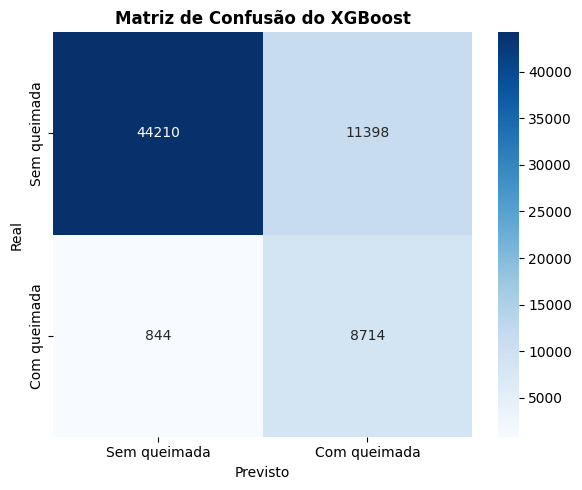

In [ ]:

results = {}

for name, model in models.items():
    print(f"\n{'=' * 40}")
    print(f"Treinando: {name}")
    print(f"{'=' * 40}")

    # treina com dados de treino
    model.fit(x_train, y_train)

    # avalia no conjunto de validação
    y_pred_val = model.predict(x_val)

    print(f"\n--- Validação ---")
    print(classification_report(y_val, y_pred_val, target_names=['Sem queimada', 'Com queimada']))

    results[name] = {
        'model': model,
        'f1': f1_score(y_val, y_pred_val),
        'precision': precision_score(y_val, y_pred_val),
        'recall': recall_score(y_val, y_pred_val),
        'accuracy': accuracy_score(y_val, y_pred_val)
    }

# comparação dos modelos na validação
print("\n\n--- Comparação na validação ---")
print(f"{'Modelo':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 65)
for name, res in results.items():
    print(f"{name:<25} {res['accuracy']:>10.4f} {res['precision']:>10.4f} {res['recall']:>10.4f} {res['f1']:>10.4f}")

# avalia o melhor modelo no conjunto de teste
best_name = max(results, key = lambda x: results[x]['f1'])
best_model = results[best_name]['model']

print(f"\n\nMelhor modelo (F1): {best_name}")
print(f"\n--- Avaliação no Teste ---")
y_pred_test = best_model.predict(x_test)
print(classification_report(y_test, y_pred_test, target_names=['Sem queimada', 'Com queimada']))

# matriz de confusão do melhor modelo
cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize = (6, 5))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels=['Sem queimada', 'Com queimada'],
            yticklabels=['Sem queimada', 'Com queimada'], ax = ax)
ax.set_title(f'Matriz de Confusão do {best_name}', fontweight = 'bold')
ax.set_ylabel('Real')
ax.set_xlabel('Previsto')
plt.tight_layout()
plt.savefig(f'{CSV_FOLDER}/matriz_confusao_{best_name.replace(" ", "_")}.png', dpi = 150)
plt.show()

# **curva ROC e AUC**

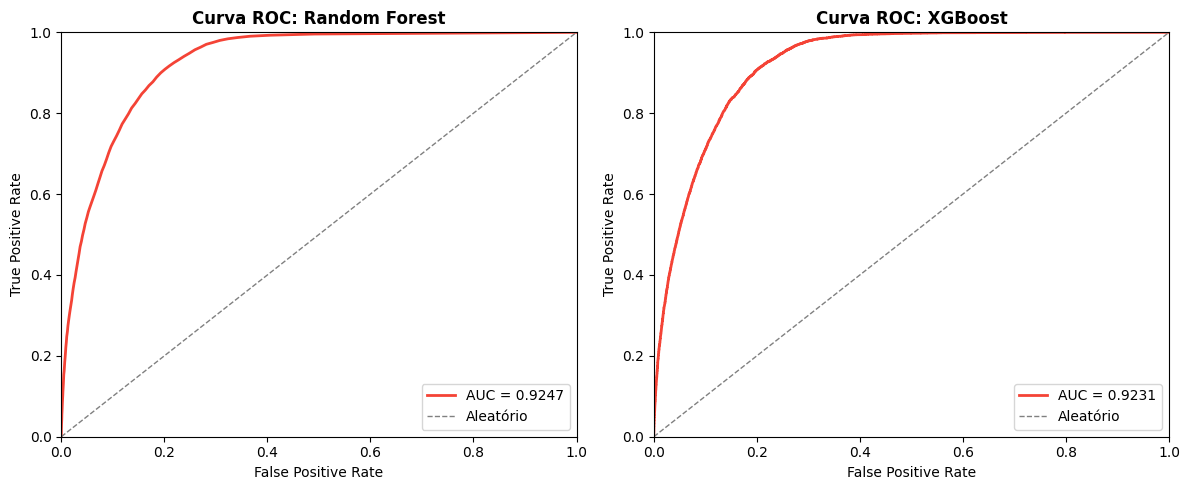


Resumo final do Teste:
Modelo                      Accuracy  Precision     Recall         F1        AUC
---------------------------------------------------------------------------
Random Forest                 0.8898     0.6979     0.4387     0.5387     0.9247
XGBoost                       0.8121     0.4333     0.9117     0.5874     0.9231


In [ ]:

fig, axes = plt.subplots(1, 2, figsize = (12, 5))

for ax, (name, res) in zip(axes, results.items()):
    model = res['model']

    # probabilidade da classe positiva
    y_prob = model.predict_proba(x_test)[:, 1]

    # calcula AUC e curva ROC
    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # armazena AUC nos resultados
    results[name]['auc'] = auc

    # plota
    ax.plot(fpr, tpr, color = '#F44336', lw = 2, label = f'AUC = {auc:.4f}')
    ax.plot([0, 1], [0, 1], color = 'gray', linestyle = '--', lw = 1, label = 'Aleatório')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'Curva ROC: {name}', fontweight = 'bold')
    ax.legend()
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig(f'{CSV_FOLDER}/roc_curve.png', dpi = 150)
plt.show()

# resumo final com AUC
print("\nResumo final do Teste:")
print(f"{'Modelo':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'AUC':>10}")
print("-" * 75)
for name, res in results.items():
    y_prob = res['model'].predict_proba(x_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    y_pred = res['model'].predict(x_test)
    print(f"{name:<25} {accuracy_score(y_test, y_pred):>10.4f} "
          f"{precision_score(y_test, y_pred):>10.4f} "
          f"{recall_score(y_test, y_pred):>10.4f} "
          f"{f1_score(y_test, y_pred):>10.4f} "
          f"{auc:>10.4f}")

In [ ]:
print("Validação:")
print(f"  F1:        {f1_score(y_val, y_pred_val):.6f}")
print(f"  Precision: {precision_score(y_val, y_pred_val):.6f}")
print(f"  Recall:    {recall_score(y_val, y_pred_val):.6f}")

print("\nTeste:")
print(f"  F1:        {f1_score(y_test, y_pred_test):.6f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.6f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.6f}")

Validação:
  F1:        0.586230
  Precision: 0.432692
  Recall:    0.908663

Teste:
  F1:        0.587395
  Precision: 0.433274
  Recall:    0.911697
